In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                      Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Imports successful ✓")

TensorFlow version: 2.21.0
Imports successful ✓


In [2]:
X_train = np.load("../models/X_train.npy")
X_test  = np.load("../models/X_test.npy")
yg_train = np.load("../models/yg_train.npy")
yg_test  = np.load("../models/yg_test.npy")
ya_train = np.load("../models/ya_train.npy")
ya_test  = np.load("../models/ya_test.npy")

print(f"Training data loaded: {X_train.shape}")
print(f"Testing data loaded : {X_test.shape}")

Training data loaded: (18966, 64, 64, 3)
Testing data loaded : (4742, 64, 64, 3)


In [3]:
inputs = Input(shape=(64, 64, 3))

# Shared feature extractor
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

# Gender output head (binary: male/female)
gender_out = Dense(1, activation='sigmoid', name='gender')(x)

# Age group output head (5 classes)
age_out = Dense(5, activation='softmax', name='age_group')(x)

model = Model(inputs=inputs, outputs=[gender_out, age_out])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,097,408 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group (Dense)   │ (None, 5)         │      1,285 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,193,094 (8.37 MB)

 Trainable params: 2,192,646 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
model.compile(
    optimizer='adam',
    loss={
        'gender': 'binary_crossentropy',
        'age_group': 'sparse_categorical_crossentropy'
    },
    metrics={
        'gender': 'accuracy',
        'age_group': 'accuracy'
    }
)
print("Model compiled ✓")

Model compiled ✓


In [5]:
checkpoint = ModelCheckpoint(
    "../models/pehchan_model.keras",
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    {'gender': yg_train, 'age_group': ya_train},
    validation_data=(X_test, {'gender': yg_test, 'age_group': ya_test}),
    epochs=30,
    batch_size=64,
    callbacks=[checkpoint, early_stop]
)

print("Training complete ✓")

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - age_group_accuracy: 0.4991 - age_group_loss: 1.6386 - gender_accuracy: 0.7258 - gender_loss: 0.7335 - loss: 2.3721
Epoch 1: val_loss improved from None to 1.56592, saving model to ../models/pehchan_model.keras

Epoch 1: finished saving model to ../models/pehchan_model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 154s 493ms/step - age_group_accuracy: 0.5692 - age_group_loss: 1.1740 - gender_accuracy: 0.7855 - gender_loss: 0.4911 - loss: 1.6660 - val_age_group_accuracy: 0.5614 - val_age_group_loss: 1.0633 - val_gender_accuracy: 0.7214 - val_gender_loss: 0.4981 - val_loss: 1.5659
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - age_group_accuracy: 0.6583 - age_group_loss: 0.8723 - gender_accuracy: 0.8513 - gender_loss: 0.3320 - loss: 1.2043
Epoch 2: val_loss improved from 1.56592 to 1.03457, saving model to ../models/pehchan_model.keras

Epoch 2: finished saving model to ../models/pehchan_model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 129s 43

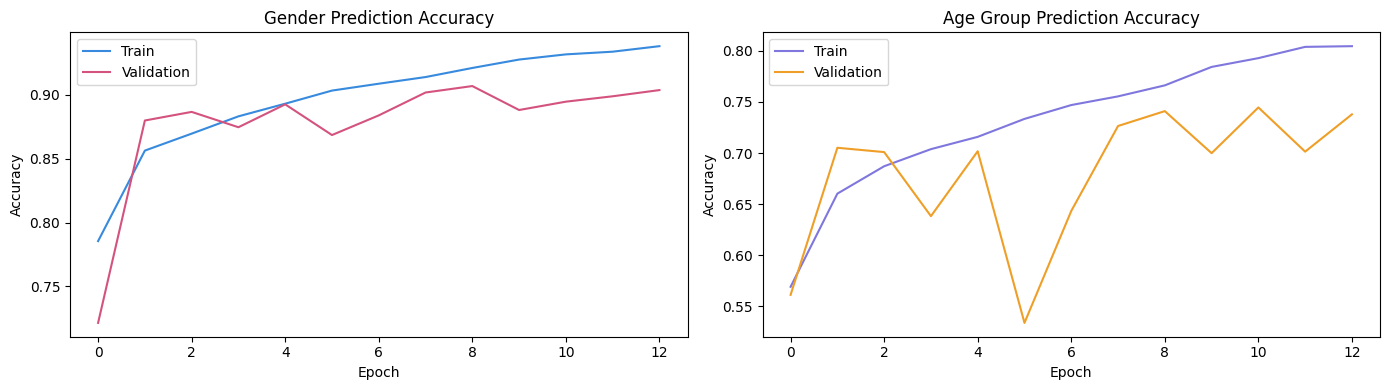

Training plots saved ✓


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gender accuracy
axes[0].plot(history.history['gender_accuracy'], label='Train', color='#378ADD')
axes[0].plot(history.history['val_gender_accuracy'], label='Validation', color='#D4537E')
axes[0].set_title('Gender Prediction Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Age accuracy
axes[1].plot(history.history['age_group_accuracy'], label='Train', color='#7F77DD')
axes[1].plot(history.history['val_age_group_accuracy'], label='Validation', color='#EF9F27')
axes[1].set_title('Age Group Prediction Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig("../training_results.png")
plt.show()
print("Training plots saved ✓")